In [1]:
import os
import time
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# ==== Paths ====
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
save_path = "best_fish_model(swin).pth"

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Datasets and Dataloaders ====
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)


🔧 Using device: cuda


In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_counts = [len(os.listdir(os.path.join(data_dir, 'train', c)))
                for c in sorted(os.listdir(os.path.join(data_dir, 'train')))]

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.arange(len(class_counts)),
                                     y=np.concatenate([[i]*count for i, count in enumerate(class_counts)]))

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


In [17]:
from torch.amp import autocast, GradScaler
# Load Swin Transformer model from timm
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()


In [18]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = 100 * correct / total
    return avg_loss, acc

In [19]:
from torch.amp import autocast, GradScaler

# Initialize scaler (outside the function)
scaler = GradScaler()

def train_model(model, train_loader, val_loader, epochs=50, patience=5):
    best_val_acc = 0.0
    best_epoch = 0
    early_stop_counter = 0

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # === Mixed precision training block ===
            with autocast(device_type=device.type):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # =======================================

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = train_loss / total
        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate(model, val_loader)

        train_loss_history.append(avg_train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_fish_model(swin).pth")
            print(f"✅ Saved best model at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")
        else:
            early_stop_counter += 1
            print(f"⏳ No improvement for {early_stop_counter} epoch(s)")

        # Print epoch results
        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

        # Stop if no improvement
        if early_stop_counter >= patience:
            print(f"🛑 Early stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\n🏁 Best Val Acc: {best_val_acc:.2f}% at epoch {best_epoch+1}")
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


In [6]:
import time
import pickle

# Start timing ⏱️
start_time = time.time()

# Call the training function
train_loss, train_acc, val_loss, val_acc = train_model(model, train_loader, val_loader, epochs=250)

# End timing ⏱️
end_time = time.time()
elapsed = end_time - start_time

# Save history to pickle
history = {
    'train_loss': train_loss,
    'train_acc': train_acc,
    'val_loss': val_loss,
    'val_acc': val_acc
}

with open("training_history(swin).pkl", "wb") as f:
    pickle.dump(history, f)

print(f"✅ History saved to training_history(new).pkl")
print(f"🕒 Total training time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")


Epoch 1/250: 100%|██████████| 195/195 [00:38<00:00,  5.10it/s]


✅ Saved best model at epoch 1 with Val Acc: 89.29%
Epoch 1:
  Train Loss: 1.1190, Train Acc: 70.16%
  Val   Loss: 0.3689, Val   Acc: 89.29%


Epoch 2/250: 100%|██████████| 195/195 [00:37<00:00,  5.25it/s]


✅ Saved best model at epoch 2 with Val Acc: 91.49%
Epoch 2:
  Train Loss: 0.3093, Train Acc: 91.00%
  Val   Loss: 0.2989, Val   Acc: 91.49%


Epoch 3/250: 100%|██████████| 195/195 [00:37<00:00,  5.22it/s]


...

⏳ No improvement for 3 epoch(s)
Epoch 9:
  Train Loss: 0.0777, Train Acc: 97.86%
  Val   Loss: 0.3545, Val   Acc: 91.34%


Epoch 10/250: 100%|██████████| 195/195 [00:37<00:00,  5.27it/s]


⏳ No improvement for 4 epoch(s)
Epoch 10:
  Train Loss: 0.0897, Train Acc: 97.18%
  Val   Loss: 0.3298, Val   Acc: 92.55%


Epoch 11/250: 100%|██████████| 195/195 [00:37<00:00,  5.24it/s]


⏳ No improvement for 5 epoch(s)
Epoch 11:
  Train Loss: 0.0666, Train Acc: 98.08%
  Val   Loss: 0.3017, Val   Acc: 92.63%
🛑 Early stopping triggered after 5 epochs without improvement.

🏁 Best Val Acc: 93.84% at epoch 6
✅ History saved to training_history(new).pkl
🕒 Total training time: 553.43 seconds (9.22 minutes)


In [20]:
with open("training_history(swin).pkl", "rb") as f:
    history = pickle.load(f)

print(history.keys())


dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


In [21]:
criterion = torch.nn.CrossEntropyLoss()

In [22]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

# === Paths ===
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Transforms ===
test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load datasets from split folders ===
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=test_val_transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=test_val_transform)
num_classes = len(train_dataset.classes)

# === Dataloaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === Model ===
# === Model ===
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False)
model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)  # ✅ Replace classification head
model.load_state_dict(torch.load("best_fish_model(swin).pth"))  # ✅ Make sure this path is correct
model = model.to(device)
model.eval()



print("✅ Model restored and ready for testing.")


✅ Model restored and ready for testing.


In [23]:
# Load best model
model.load_state_dict(torch.load("best_fish_model(swin).pth"))
model.eval()

# Evaluate on validation set
val_loss_final, val_acc_final = evaluate(model, val_loader)

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader)

# Print results
print(f" Final Validation Accuracy: {val_acc_final:.2f}%, Validation Loss: {val_loss_final:.4f}")
print(f" Final Test Accuracy:      {test_acc:.2f}%, Test Loss:      {test_loss:.4f}")

 Final Validation Accuracy: 93.84%, Validation Loss: 0.2253
 Final Test Accuracy:      92.39%, Test Loss:      0.2898


In [24]:
import os
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# === Paths and Device ===
folder_path = r"C:\Users\STUDENT\Downloads\test_images"
model_path = "best_fish_model(swin).pth"
class_names = sorted(os.listdir(r"C:\Users\STUDENT\Downloads\FishDataset_Split/Train"))
device = torch.device('cpu')  # Or use 'cuda' if available

# === Image Transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Required for convnext_tiny
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load convnext_tiny Model ===
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False)
model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)  # ✅ Replace classification head
model.load_state_dict(torch.load("best_fish_model(swin).pth"))  # ✅ Make sure this path is correct
model = model.to(device)
model.eval()

print("✅swin_tiny model loaded and ready for inference.")

# === Run Inference on Images ===
for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    try:
        img_path = os.path.join(folder_path, filename)
        image = Image.open(img_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            prob, pred = torch.max(probabilities, 1)

        predicted_class = class_names[pred.item()]
        confidence = prob.item() * 100

        print(f"📷 {filename} →  Predicted: {predicted_class} ({confidence:.2f}%)")

        # Optional: Visualize prediction
        # plt.imshow(image)
        # plt.title(f"{filename}\nPredicted: {predicted_class} ({confidence:.2f}%)")
        # plt.axis('off')
        # plt.show()
        # plt.close()

    except Exception as e:
        print(f"⚠️ Error processing {filename}: {e}")
        continue


✅swin_tiny model loaded and ready for inference.
📷 1.jpg →  Predicted: Bangus (100.00%)
📷 2.jpg →  Predicted: Bangus (100.00%)
📷 4.jpg →  Predicted: Gold Fish (100.00%)
📷 5.jpg →  Predicted: Freshwater Eel (83.96%)
📷 6.jpg →  Predicted: Gourami (100.00%)
📷 7.jpg →  Predicted: Gold Fish (100.00%)


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import torch

def compute_metrics(model, loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Compute metrics ===
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    # === Print ===
    print(f"🔍 Precision: {precision:.4f}")
    print(f"🔁 Recall:    {recall:.4f}")
    print(f"⭐ F1 Score:  {f1:.4f}")

    if class_names:
        print("\n📋 Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))

    # Optional: Confusion Matrix

    return precision, recall, f1


In [26]:
# 📦 Call the function to trigger execution
class_names = test_dataset.classes  # or train_dataset.classes if needed
precision, recall, f1 = compute_metrics(model, test_loader, class_names)

🔍 Precision: 0.9256
🔁 Recall:    0.9239
⭐ F1 Score:  0.9236

📋 Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.69      0.89      0.77        27
        Big Head Carp       0.81      0.78      0.79        32
   Black Spotted Barb       0.94      1.00      0.97        31
              Catfish       0.90      0.92      0.91        50
       Climbing Perch       0.87      0.83      0.85        24
 Fourfinger Threadfin       0.96      0.83      0.89        30
       Freshwater Eel       0.95      0.93      0.94        42
       Glass Perchlet       0.91      0.97      0.94        61
                 Goby       0.91      0.92      0.91        93
            Gold Fish       0.97      1.00      0.99        34
              Gourami       0.96      0.98      0.97        48
           Grass Carp       0.97      0.97      0.97       190
 Green Spotted Puffer       0.95      1.00      0.97        18
          Indian Carp       0.9

In [2]:
import os
import torch
import timm
import pickle
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ==== Config ====
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
k = 5
epochs = 10
batch_size = 32
learning_rate = 1e-4

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Dataset & Labels ====
full_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
labels = [sample[1] for sample in full_dataset]
num_classes = len(full_dataset.classes)

# ==== Train Function ====
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss_hist.append(running_loss / total)
        train_acc_hist.append(correct / total)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss_hist.append(val_loss / val_total)
        val_acc_hist.append(val_correct / val_total)

        print(f"📚 Epoch {epoch+1}/{epochs}: Train Acc={train_acc_hist[-1]:.4f}, Val Acc={val_acc_hist[-1]:.4f}")

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

# ==== Cross-Validation ====
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n🔁 Fold {fold+1}/{k}")
    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)
    train_subset.dataset.transform = train_transform
    val_subset.dataset.transform = val_transform

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)

    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_loss, train_acc, val_loss, val_acc = train_model(model, train_loader, val_loader,
                                                           criterion, optimizer, epochs)

    fold_result = {
        "fold": fold + 1,
        "train_acc": train_acc[-1],
        "val_acc": val_acc[-1],
        "train_loss": train_loss[-1],
        "val_loss": val_loss[-1],
        "train_acc_hist": train_acc,
        "val_acc_hist": val_acc,
        "train_loss_hist": train_loss,
        "val_loss_hist": val_loss
    }
    cv_results.append(fold_result)

    torch.save(model.state_dict(), f"swin_fold{fold+1}.pth")
    print(f"💾 Saved model for Fold {fold+1}")

# ==== Save Cross-Validation History ====
with open("swin_crossval_history.pkl", "wb") as f:
    pickle.dump(cv_results, f)

# ==== Summary ====
print("\n📊 Cross-Validation Summary:")
for r in cv_results:
    print(f"Fold {r['fold']}: Val Acc = {r['val_acc']:.4f}, Val Loss = {r['val_loss']:.4f}")



🔁 Fold 1/5
📚 Epoch 1/10: Train Acc=0.7077, Val Acc=0.8882
📚 Epoch 2/10: Train Acc=0.9463, Val Acc=0.9155
📚 Epoch 3/10: Train Acc=0.9835, Val Acc=0.9300
📚 Epoch 4/10: Train Acc=0.9833, Val Acc=0.9316
📚 Epoch 5/10: Train Acc=0.9857, Val Acc=0.9276
📚 Epoch 6/10: Train Acc=0.9889, Val Acc=0.9220
📚 Epoch 7/10: Train Acc=0.9976, Val Acc=0.9389
📚 Epoch 8/10: Train Acc=0.9958, Val Acc=0.9212
📚 Epoch 9/10: Train Acc=0.9853, Val Acc=0.9187
📚 Epoch 10/10: Train Acc=0.9837, Val Acc=0.9195
💾 Saved model for Fold 1

🔁 Fold 2/5
📚 Epoch 1/10: Train Acc=0.7093, Val Acc=0.8850
📚 Epoch 2/10: Train Acc=0.9423, Val Acc=0.8922
📚 Epoch 3/10: Train Acc=0.9821, Val Acc=0.9059
📚 Epoch 4/10: Train Acc=0.9871, Val Acc=0.9155
📚 Epoch 5/10: Train Acc=0.9940, Val Acc=0.9107
📚 Epoch 6/10: Train Acc=0.9946, Val Acc=0.9083
📚 Epoch 7/10: Train Acc=0.9964, Val Acc=0.9195
📚 Epoch 8/10: Train Acc=0.9817, Val Acc=0.8681
📚 Epoch 9/10: Train Acc=0.9781, Val Acc=0.8930
📚 Epoch 10/10: Train Acc=0.9859, Val Acc=0.9220
💾 Saved m

In [4]:
# Same imports, transforms, dataset, train_model(), etc. from previous block
# Just rerun this tuning block separately after that setup

learning_rates = [1e-4, 5e-5, 1e-5]

batch_sizes = [32, 64]
tuning_results = []

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n🔧 Tuning for LR={lr}, Batch Size={bs}")
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_metrics = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
            print(f"   🔁 Fold {fold+1}/5")

            train_subset = Subset(full_dataset, train_idx)
            val_subset = Subset(full_dataset, val_idx)
            train_subset.dataset.transform = train_transform
            val_subset.dataset.transform = val_transform

            train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=2)
            val_loader = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=2)

            model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
            model = model.to(device)

            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.CrossEntropyLoss()

            _, _, _, val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

            fold_metrics.append(val_acc[-1])

        avg_val_acc = np.mean(fold_metrics)
        tuning_results.append({"lr": lr, "bs": bs, "avg_val_acc": avg_val_acc})
        print(f"✅ LR={lr}, BS={bs} → Avg Val Acc: {avg_val_acc:.4f}")

# Save tuning results
with open("swin_tuning_results.pkl", "wb") as f:
    pickle.dump(tuning_results, f)

# Print best hyperparameter combination
best = max(tuning_results, key=lambda x: x["avg_val_acc"])
print(f"\n🏆 Best Config → LR={best['lr']}, BS={best['bs']} with Val Acc={best['avg_val_acc']:.4f}")



🔧 Tuning for LR=0.0001, Batch Size=32
   🔁 Fold 1/5
📚 Epoch 1/10: Train Acc=0.7053, Val Acc=0.9010
📚 Epoch 2/10: Train Acc=0.9431, Val Acc=0.9171
📚 Epoch 3/10: Train Acc=0.9805, Val Acc=0.9332
📚 Epoch 4/10: Train Acc=0.9895, Val Acc=0.9252
📚 Epoch 5/10: Train Acc=0.9940, Val Acc=0.9364
📚 Epoch 6/10: Train Acc=0.9857, Val Acc=0.9252
📚 Epoch 7/10: Train Acc=0.9875, Val Acc=0.9260
📚 Epoch 8/10: Train Acc=0.9795, Val Acc=0.8858
📚 Epoch 9/10: Train Acc=0.9827, Val Acc=0.9155
📚 Epoch 10/10: Train Acc=0.9932, Val Acc=0.9364
   🔁 Fold 2/5
📚 Epoch 1/10: Train Acc=0.7009, Val Acc=0.8833
📚 Epoch 2/10: Train Acc=0.9419, Val Acc=0.9204
📚 Epoch 3/10: Train Acc=0.9799, Val Acc=0.9115
📚 Epoch 4/10: Train Acc=0.9911, Val Acc=0.9083
📚 Epoch 5/10: Train Acc=0.9883, Val Acc=0.9010
📚 Epoch 6/10: Train Acc=0.9889, Val Acc=0.8898
📚 Epoch 7/10: Train Acc=0.9839, Val Acc=0.8930
📚 Epoch 8/10: Train Acc=0.9841, Val Acc=0.8938
📚 Epoch 9/10: Train Acc=0.9895, Val Acc=0.9075
📚 Epoch 10/10: Train Acc=0.9924, Val Ac

In [5]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

# ==== Paths ====
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Load and Combine Train + Val ====
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=train_transform)
full_train_dataset = ConcatDataset([train_dataset, val_dataset])

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==== Model ====
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

# ==== Training Setup ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-05)
epochs = 15

# ==== Training Loop ====
print("🚀 Training final Swin-Tiny model on full training set...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in DataLoader(full_train_dataset, batch_size=32, shuffle=True, num_workers=2):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"📘 Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Acc = {epoch_acc*100:.2f}%")

# ==== Save Final Model ====
torch.save(model.state_dict(), "final_swin_model.pth")
print("✅ Final Swin-Tiny model saved as 'final_swin_model.pth'")

# ==== Evaluation on Test Set ====
print("\n🧪 Evaluating on Test Set...")
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ==== Accuracy ====
test_accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"\n✅ Final Test Accuracy: {test_accuracy:.2f}%")

# ==== Classification Report ====
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# ==== Precision, Recall, F1 Scores ====
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("\n📈 Performance Summary:")
print(f"🔹 Macro Precision : {precision_macro:.4f}")
print(f"🔹 Macro Recall    : {recall_macro:.4f}")
print(f"🔹 Macro F1 Score  : {f1_macro:.4f}")
print(f"🔸 Weighted Precision : {precision_weighted:.4f}")
print(f"🔸 Weighted Recall    : {recall_weighted:.4f}")
print(f"🔸 Weighted F1 Score  : {f1_weighted:.4f}")


🔧 Using device: cuda
🚀 Training final Swin-Tiny model on full training set...
📘 Epoch 1: Loss = 1.1326, Acc = 69.95%
📘 Epoch 2: Loss = 0.2776, Acc = 92.35%
📘 Epoch 3: Loss = 0.1480, Acc = 96.20%
📘 Epoch 4: Loss = 0.0925, Acc = 97.86%
📘 Epoch 5: Loss = 0.0674, Acc = 98.51%
📘 Epoch 6: Loss = 0.0501, Acc = 98.99%
📘 Epoch 7: Loss = 0.0542, Acc = 98.59%
📘 Epoch 8: Loss = 0.0441, Acc = 98.91%
📘 Epoch 9: Loss = 0.0425, Acc = 98.82%
📘 Epoch 10: Loss = 0.0501, Acc = 98.57%
📘 Epoch 11: Loss = 0.0342, Acc = 99.26%
📘 Epoch 12: Loss = 0.0329, Acc = 99.20%
📘 Epoch 13: Loss = 0.0341, Acc = 99.11%
📘 Epoch 14: Loss = 0.0319, Acc = 99.12%
📘 Epoch 15: Loss = 0.0325, Acc = 99.20%
✅ Final Swin-Tiny model saved as 'final_swin_model.pth'

🧪 Evaluating on Test Set...

✅ Final Test Accuracy: 94.22%

📊 Classification Report:
                       precision    recall  f1-score   support

               Bangus      0.955     0.778     0.857        27
        Big Head Carp      0.886     0.969     0.925        32

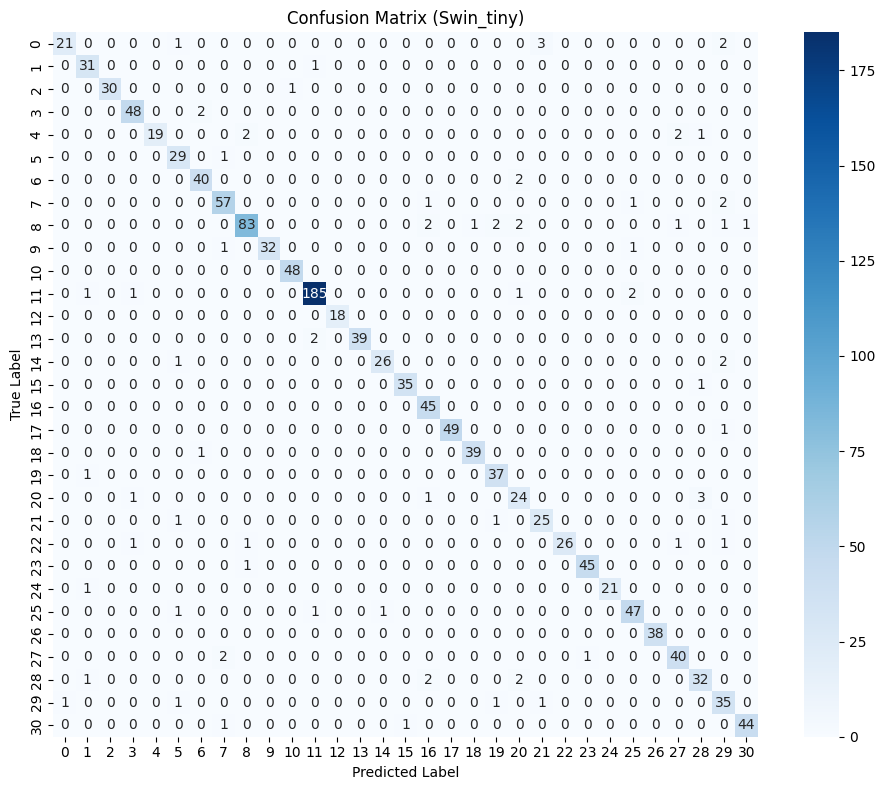

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# === Generate confusion matrix ===
cm = confusion_matrix(y_true, y_pred)
num_classes = cm.shape[0]

# === Plot ===
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=np.arange(num_classes),
            yticklabels=np.arange(num_classes),
            linewidths=0, linecolor='white', square=True)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Swin_tiny)")
plt.tight_layout()
plt.show()